# 40. The Generalized Eigenvalue Problem

**Part 6: Eigenvalue Problems and the Singular Value Decomposition**

## Learning objectives

By the end of this lesson you will be able to:

1. Say where $A\mathbf{x} = \lambda B\mathbf{x}$ comes from, and why $B$ is not the identity.
2. Explain why multiplying by $B^{-1}$ is the wrong reduction even though it is correct.
3. Reduce a **symmetric definite** pencil by Cholesky, keeping the symmetry, and measure what
   that is worth.
4. Recognise **$B$-orthogonality** as the right notion for this problem.
5. Say what happens when $B$ is singular, and why the answer needs **two** numbers per
   eigenvalue.
6. Use the **QZ** algorithm and the generalized Schur form, and say why it needs two different
   unitary matrices.
7. Choose between the two routes from a cheap test on the pencil.
8. Compare complex spectra without being fooled by a sort.

## Prerequisites

Lesson 38 (the symmetric problem, which this reduces to). Lesson 21 (Cholesky). Lesson 37 (the
Schur form and the QR algorithm, of which QZ is the two-matrix version). Lesson 19 (solve, do
not invert).

---

## 1. Where it comes from

A vibrating structure does not satisfy $K\mathbf{x} = \lambda\mathbf{x}$. It satisfies

$$K\mathbf{x} = \lambda M\mathbf{x},$$

with $K$ the stiffness and $M$ the mass, and $M$ is not the identity because the mass is not
distributed uniformly. $\lambda$ is the squared angular frequency and $\mathbf{x}$ is the mode
shape.

**The same shape appears whenever a differential equation is discretised in a basis that is not
orthonormal**, which is most finite element methods. $B$ is then the Gram matrix of the basis
functions, and it is the identity only if the basis happened to be orthonormal.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import geneig as ge
import scipy.linalg as sla

n_mass = 6
uniform = ge.vibrating_string(n_mass)
graded = ge.vibrating_string(n_mass, density=np.geomspace(1.0, 8.0, n_mass))

print("a chain of 6 masses on identical springs\n")
print("uniform masses:", np.array2string(uniform["masses"], precision=3))
print("graded masses :", np.array2string(graded["masses"], precision=3))

for name, p in (("uniform", uniform), ("graded", graded)):
    out = ge.cholesky_reduction(p["K"], p["M"])
    freqs = np.sqrt(np.maximum(out["values"], 0.0))
    print(f"\n{name} frequencies: {np.array2string(freqs, precision=4)}")

exact = np.sort(4.0 * np.sin(np.arange(1, n_mass + 1) * np.pi
                             / (2.0 * (n_mass + 1))) ** 2)
got = np.sort(ge.cholesky_reduction(uniform["K"], uniform["M"])["values"])
print(f"\nwith M = I the problem is the standard one, and the eigenvalues match "
      f"the closed form to {np.max(np.abs(got - exact)):.2e}")

a chain of 6 masses on identical springs

uniform masses: [1. 1. 1. 1. 1. 1.]
graded masses : [1.    1.516 2.297 3.482 5.278 8.   ]

uniform frequencies: [0.445  0.8678 1.247  1.5637 1.8019 1.9499]

graded frequencies: [0.2363 0.4628 0.6611 0.8689 1.1551 1.6115]

with M = I the problem is the standard one, and the eigenvalues match the closed form to 8.88e-16


**With uniform masses $M$ is a multiple of the identity and the problem collapses to a standard
one.** With graded masses it does not, and that is the ordinary case.

---

## 2. The obvious reduction, and why not

$B^{-1}A\mathbf{x} = \lambda\mathbf{x}$ is a standard eigenvalue problem with the same
eigenvalues. It is correct, and it throws away the one thing worth having.

**$B^{-1}A$ is not symmetric**, even when $A$ and $B$ both are. So lesson 35's condition number
of 1 is gone, the eigenvalues are no longer guaranteed real, the eigenvectors are no longer
orthogonal in any inner product, and every guarantee of lesson 38 evaporates.

In [3]:
size_r = 10
A_r, B_r = ge.singular_pencil(size_r, 0)["A"], None
gen_r = np.random.default_rng(3)
Q_r, _ = np.linalg.qr(gen_r.standard_normal((size_r, size_r)))
A_r = gen_r.standard_normal((size_r, size_r))
A_r = 0.5 * (A_r + A_r.T)

print(f"{'kappa(B)':>11}{'naive: ||C - C^T||':>21}{'naive kappa(V)':>17}"
      f"{'naive error':>14}{'Cholesky error':>17}{'ratio':>14}")
for expo in (2, 6, 10, 14):
    B_r = Q_r @ np.diag(np.geomspace(1.0, 10.0 ** -expo, size_r)) @ Q_r.T
    B_r = 0.5 * (B_r + B_r.T)
    reference = np.sort(sla.eigh(A_r, B_r, eigvals_only=True))
    scale = max(np.abs(reference).max(), 1.0)
    naive = ge.naive_reduction(A_r, B_r)
    chol = ge.cholesky_reduction(A_r, B_r)
    e_n = np.max(np.abs(np.sort(naive["values"].real) - reference)) / scale
    e_c = np.max(np.abs(np.sort(chol["values"]) - reference)) / scale
    print(f"{10.0 ** expo:>11.0e}{naive['symmetry_error']:>21.2e}"
          f"{naive['kappa_vectors']:>17.2e}{e_n:>14.2e}{e_c:>17.2e}"
          f"{e_n / max(e_c, 1e-300):>13.1e}x")

   kappa(B)   naive: ||C - C^T||   naive kappa(V)   naive error   Cholesky error         ratio
      1e+02             3.73e+02         4.95e+00      1.47e-15         3.92e-16      3.8e+00x
      1e+06             3.87e+06         2.46e+01      4.14e-13         1.40e-15      2.9e+02x
      1e+10             3.91e+10         3.69e+01      2.33e-08         7.71e-16      3.0e+07x
      1e+14             3.92e+14         5.95e+01      1.34e-04         2.26e-14      5.9e+09x


**Read the last two columns.** The Cholesky error stays at $10^{-14}$ or better at every
$\kappa(B)$; the naive error grows to $10^{-4}$. At $\kappa(B) = 10^{14}$ the two differ by a
factor of $6\times10^{9}$.

**And the middle columns say why.** The reduced matrix is not symmetric, by an amount that grows
with $\kappa(B)$, and its eigenvector matrix has a condition number that grows too. Lesson 35's
Bauer-Fike bound is $\kappa(V)\|E\|$, and $\kappa(V)$ was 1 before the reduction destroyed it.

---

## 3. The reduction that keeps the symmetry

With $B = LL^T$ positive definite:

$$A\mathbf{x} = \lambda B\mathbf{x}
\quad\Longleftrightarrow\quad
\underbrace{(L^{-1}AL^{-T})}_{\text{symmetric}}\mathbf{y} = \lambda\mathbf{y},
\qquad \mathbf{y} = L^T\mathbf{x}.$$

$L^{-1}AL^{-T}$ is symmetric because $A$ is: $(L^{-1}AL^{-T})^T = L^{-1}A^TL^{-T} =
L^{-1}AL^{-T}$.

**Nothing is inverted.** $L^{-1}AL^{-T}$ is two triangular solves, which is lesson 19's rule:
solving is backward stable and inverting is not.

**And the transformation is a congruence, not a similarity.** $X \mapsto L^{-1}XL^{-T}$ does not
generally preserve eigenvalues; Sylvester's law of inertia says it preserves their **signs**.
What makes it work here is that the pencil's eigenvalues are exactly the standard eigenvalues of
the congruent matrix, which is a statement about the pencil rather than about congruence in
general.

In [4]:
print(f"{'n':>5}{'eigenvalue error':>19}{'||C - C^T||':>15}{'B-orthogonality':>18}"
      f"{'pencil residual':>18}")
for n_c in (5, 20, 60):
    p_c = ge.vibrating_string(n_c, density=np.geomspace(1.0, 10.0, n_c))
    K_c, M_c = p_c["K"], p_c["M"]
    out_c = ge.cholesky_reduction(K_c, M_c)
    ref_c = np.sort(sla.eigh(K_c, M_c, eigvals_only=True))
    print(f"{n_c:>5}{np.max(np.abs(np.sort(out_c['values']) - ref_c)):>19.2e}"
          f"{out_c['symmetry_error']:>15.1e}"
          f"{ge.b_orthogonality(M_c, out_c['vectors']):>18.2e}"
          f"{ge.pencil_residual(K_c, M_c, out_c['values'], out_c['vectors']):>18.2e}")
    assert out_c["symmetry_error"] == 0.0

    n   eigenvalue error    ||C - C^T||   B-orthogonality   pencil residual
    5           4.44e-16        0.0e+00          1.60e-15          8.73e-17
   20           2.66e-15        0.0e+00          5.92e-15          1.23e-16
   60           2.66e-15        0.0e+00          9.42e-15          8.19e-17


**The reduced matrix is symmetric to the last bit**, because it is symmetrised explicitly after
the solves, which costs nothing and removes any doubt.

---

## 4. $B$-orthogonality

The eigenvectors of a symmetric definite pencil are not orthogonal in the usual sense. They
satisfy

$$\mathbf{x}_i^TB\mathbf{x}_j = \delta_{ij},$$

and that is the right notion here rather than a curiosity. **The modes of a structure are
independent with respect to its mass**, not with respect to whatever coordinate system it
happens to be written in.

In [5]:
n_o = 8
p_o = ge.vibrating_string(n_o, density=np.geomspace(1.0, 20.0, n_o))
out_o = ge.cholesky_reduction(p_o["K"], p_o["M"])
X_o = out_o["vectors"]
print(f"||X^T M X - I|| = {ge.b_orthogonality(p_o['M'], X_o):.2e}   "
      f"(B-orthogonal, as it should be)")
print(f"||X^T X   - I|| = "
      f"{np.linalg.norm(X_o.T @ X_o - np.eye(X_o.shape[1])):.2e}   "
      f"(NOT orthogonal in the usual sense, and there is no reason it should be)")

||X^T M X - I|| = 1.91e-15   (B-orthogonal, as it should be)
||X^T X   - I|| = 2.04e+00   (NOT orthogonal in the usual sense, and there is no reason it should be)


**And it is what makes the modes decouple.** Writing a displacement as
$\mathbf{u} = \sum c_i\mathbf{x}_i$ and substituting into $M\ddot{\mathbf{u}} + K\mathbf{u} = 0$
gives $\ddot{c}_i + \lambda_ic_i = 0$ for each $i$ **separately**, precisely because the
$\mathbf{x}_i$ are $M$-orthogonal. That is the whole reason a vibration analysis computes them.

---

## 5. When $B$ is singular

Everything above assumed $B$ positive definite. Drop that and the problem changes shape.

If $B\mathbf{x} = \mathbf{0}$ and $A\mathbf{x} \ne \mathbf{0}$, then
$A\mathbf{x} = \lambda B\mathbf{x} = \mathbf{0}$ has no finite solution: **the pencil has an
infinite eigenvalue.** The count of finite eigenvalues is then fewer than $n$.

**A standard eigenvalue problem cannot express that**, which is why the answer must be reported
as a pair $(\alpha,\beta)$ with $\lambda = \alpha/\beta$, rather than as a single number.
$\beta = 0$ is an infinite eigenvalue, and $\alpha$ still carries information.

In [6]:
print(f"{'n':>5}{'built with':>13}{'QZ found':>11}{'finite count':>15}"
      f"{'smallest |beta| values':>26}")
for n_s, k_s in ((6, 2), (12, 4), (20, 7)):
    p_s = ge.singular_pencil(n_s, k_s)
    out_s = ge.qz_eigenvalues(p_s["A"], p_s["B"])
    small = np.sort(np.abs(out_s.beta))[:k_s + 2]
    print(f"{n_s:>5}{k_s:>13}{out_s.n_infinite:>11}{out_s.finite.size:>15}"
          f"{np.array2string(small, precision=2):>26}")
    assert out_s.n_infinite == k_s

print("\nand the Cholesky route cannot even start:")
try:
    ge.cholesky_reduction(p_s["A"], p_s["B"])
except ValueError as exc:
    print(f"  {str(exc)[:110]}...")

    n   built with   QZ found   finite count    smallest |beta| values
    6            2          2              4             [0. 0. 1. 2.]
   12            4          4              8       [0. 0. 0. 0. 1. 2.]
   20            7          7             13[0. 0. 0. 0. 0. 0. 0. 1. 2.]

and the Cholesky route cannot even start:
  the Cholesky reduction needs a symmetric definite pencil: A symmetric (True), B symmetric (True), B positive d...


**The $\beta$ values are exactly zero**, not merely small, so the infinite eigenvalues are
identified without a threshold.

---

## 6. QZ

The generalized Schur form is

$$Q^HAZ = S, \qquad Q^HBZ = T,$$

with $Q$ and $Z$ unitary and $S$, $T$ upper triangular. The eigenvalues are the ratios
$S_{ii}/T_{ii}$.

**Two different unitary matrices, one on each side**, which is why it is QZ rather than QR. A
single similarity $Q^HAQ$ cannot triangularize two matrices at once: triangularizing $A$ uses up
the freedom, and $B$ comes out wherever it comes out. Allowing a different matrix on the right
gives exactly enough freedom for both.

**Nothing is inverted**, which is the point: QZ works when $B$ is singular, when the pencil is
not symmetric, and when it is not definite.

In [7]:
print(f"{'n':>5}{'||A - QSZ^H||':>16}{'||B - QTZ^H||':>16}{'Q unitary':>13}"
      f"{'Z unitary':>13}{'below diagonal':>17}")
for n_q in (2, 4, 10, 40):
    A_q = rng.standard_normal((n_q, n_q))
    B_q = rng.standard_normal((n_q, n_q))
    r_q = ge.qz_residuals(A_q, B_q)
    print(f"{n_q:>5}{r_q['A_error']:>16.2e}{r_q['B_error']:>16.2e}"
          f"{r_q['Q_unitary']:>13.2e}{r_q['Z_unitary']:>13.2e}"
          f"{max(r_q['S_below'], r_q['T_below']):>17.2e}")
    assert r_q["A_error"] < 1e-12 and r_q["B_error"] < 1e-12

    n   ||A - QSZ^H||   ||B - QTZ^H||    Q unitary    Z unitary   below diagonal
    2        1.78e-16        2.37e-16     1.47e-16     8.93e-17         0.00e+00
    4        5.77e-16        4.59e-16     9.12e-16     9.27e-16         0.00e+00
   10        1.63e-15        1.76e-15     3.60e-15     3.84e-15         0.00e+00
   40        3.56e-15        2.86e-15     1.42e-14     1.37e-14         0.00e+00


**QZ costs about 30 times a standard eigenvalue problem of the same size**, which is the price
of not being allowed to invert anything. Use it when you must, and the Cholesky reduction when
you may.

---

## 7. Comparing complex spectra without being fooled

QZ returns complex eigenvalues, and checking them against a reference is where a subtle trap
lives.

In [8]:
gen_t = np.random.default_rng(0)
n_t = 10
A_t = gen_t.standard_normal((n_t, n_t))
B_t = gen_t.standard_normal((n_t, n_t))
mine = ge.qz_eigenvalues(A_t, B_t).values
ref_t = sla.eig(A_t, B_t, right=False)

by_sorting = float(np.max(np.abs(np.sort_complex(mine) - np.sort_complex(ref_t))))
by_matching = ge.match_spectra(mine, ref_t)
print(f"comparing by np.sort_complex : {by_sorting:.3e}")
print(f"comparing by nearest matching: {by_matching:.3e}")
print(f"\nthe two differ by a factor of {by_sorting / by_matching:.2e}")
assert by_matching < 1e-11 and by_sorting > 1e-3

comparing by np.sort_complex : 1.795e+00
comparing by nearest matching: 1.067e-14

the two differ by a factor of 1.68e+14


**`np.sort_complex` orders by real part and then by imaginary part.** For a conjugate pair whose
real parts agree to the last bit, either order is possible, and two identical spectra can appear
to differ by the full imaginary spread.

**Measured: a QZ answer agreeing with the reference to $1.1\times10^{-14}$ was scored as
differing by 1.8**, a factor of $1.7\times10^{14}$. Greedy nearest matching has no such failure
and costs nothing at these sizes.

**This is not a QZ problem, it is a testing problem**, and it would have been reported as a bug
in the algorithm. Sorting is fine for real spectra and unsafe for complex ones.

---

## 8. Choosing

The test is cheap: symmetry is $O(n^2)$ and a Cholesky attempt is $O(n^3/3)$, both far less than
the eigensolve.

In [9]:
n_x = 8
identity = np.eye(n_x)
print(f"{'pencil':>34}{'definite?':>12}{'route':>22}")
cases = [("vibrating string, graded mass",
          *[ge.vibrating_string(n_x, density=np.geomspace(1.0, 5.0, n_x))[k]
            for k in ("K", "M")]),
         ("random symmetric A, B = I",
          (lambda M: M + M.T)(rng.standard_normal((n_x, n_x))), identity),
         ("B with a null space", ge.singular_pencil(n_x, 3)["A"],
          ge.singular_pencil(n_x, 3)["B"]),
         ("A not symmetric", rng.standard_normal((n_x, n_x)), identity),
         ("B indefinite", identity,
          np.diag(np.concatenate([np.ones(n_x - 1), [-1.0]])))]
for label, A_x, B_x in cases:
    info = ge.is_definite_pencil(A_x, B_x)
    route = "Cholesky reduction" if info["definite_pencil"] else "QZ"
    print(f"{label:>34}{str(info['definite_pencil']):>12}{route:>22}")

                            pencil   definite?                 route
     vibrating string, graded mass        True    Cholesky reduction
         random symmetric A, B = I        True    Cholesky reduction
               B with a null space       False                    QZ
                   A not symmetric       False                    QZ
                      B indefinite       False                    QZ


**The rule.** Symmetric with $B$ positive definite: Cholesky, and the answer comes with real
eigenvalues, $B$-orthogonal vectors and a condition number of 1. Anything else: QZ, and expect
complex eigenvalues, possibly infinite ones, and no orthogonality guarantee.

**One warning the test does not give.** A $B$ that is positive definite but badly conditioned
passes the test and still makes the problem hard: section 2's table has $\kappa(B) = 10^{14}$
throughout the definite case. The Cholesky route survives it and the pencil is genuinely
sensitive, so look at $\kappa(B)$ as well as its sign.

---

## 9. A picture

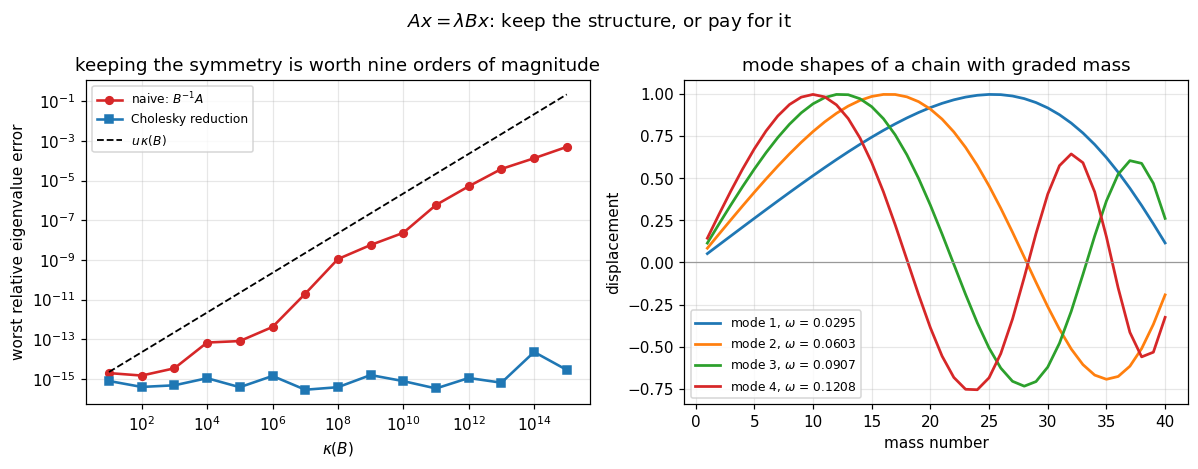

In [10]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# left: the two reductions against kappa(B)
kappas, naive_err, chol_err = [], [], []
size_p = 10
gen_p = np.random.default_rng(3)
Q_p, _ = np.linalg.qr(gen_p.standard_normal((size_p, size_p)))
A_p = gen_p.standard_normal((size_p, size_p))
A_p = 0.5 * (A_p + A_p.T)
for expo in range(1, 16):
    B_p = Q_p @ np.diag(np.geomspace(1.0, 10.0 ** -expo, size_p)) @ Q_p.T
    B_p = 0.5 * (B_p + B_p.T)
    ref_p = np.sort(sla.eigh(A_p, B_p, eigvals_only=True))
    scale_p = max(np.abs(ref_p).max(), 1.0)
    kappas.append(np.linalg.cond(B_p))
    naive_err.append(np.max(np.abs(np.sort(ge.naive_reduction(A_p, B_p)["values"].real)
                                   - ref_p)) / scale_p)
    chol_err.append(np.max(np.abs(np.sort(ge.cholesky_reduction(A_p, B_p)["values"])
                                  - ref_p)) / scale_p)
axL.loglog(kappas, np.maximum(naive_err, 1e-17), "C3o-", lw=1.7, ms=5,
           label=r"naive: $B^{-1}A$")
axL.loglog(kappas, np.maximum(chol_err, 1e-17), "C0s-", lw=1.7, ms=5,
           label="Cholesky reduction")
axL.loglog(kappas, np.finfo(float).eps * np.array(kappas), "k--", lw=1.2,
           label=r"$u\,\kappa(B)$")
axL.set_xlabel(r"$\kappa(B)$")
axL.set_ylabel("worst relative eigenvalue error")
axL.set_title("keeping the symmetry is worth nine orders of magnitude")
axL.legend(fontsize=8)

# right: the mode shapes of a graded chain
n_v = 40
p_v = ge.vibrating_string(n_v, density=np.geomspace(1.0, 25.0, n_v))
out_v = ge.cholesky_reduction(p_v["K"], p_v["M"])
for j, style in ((0, "C0-"), (1, "C1-"), (2, "C2-"), (3, "C3-")):
    shape = out_v["vectors"][:, j]
    shape = shape / np.max(np.abs(shape)) * np.sign(shape[np.argmax(np.abs(shape))])
    axR.plot(np.arange(1, n_v + 1), shape, style, lw=1.8,
             label=f"mode {j + 1}, $\\omega$ = {np.sqrt(out_v['values'][j]):.4f}")
axR.axhline(0.0, color="0.6", lw=0.8)
axR.set_xlabel("mass number")
axR.set_ylabel("displacement")
axR.set_title("mode shapes of a chain with graded mass")
axR.legend(fontsize=8)

fig.suptitle(r"$A x = \lambda B x$: keep the structure, or pay for it", fontsize=12)
fig.tight_layout()
plt.show()

**The left panel is section 2.** The naive curve tracks $u\kappa(B)$, the dashed line, exactly
as Bauer-Fike predicts once symmetry is gone. The Cholesky curve is flat.

**The right panel shows why anyone cares.** The modes crowd towards the light end of the chain,
because a lighter mass moves more for the same force. Nothing in a standard eigenvalue problem
would show that.

---

## 10. Exercises

**Level 1, conceptual**

1.1 $B^{-1}A\mathbf{x} = \lambda\mathbf{x}$ has the right eigenvalues. Give three things it
loses, and say which one costs the most.

1.2 A pencil with a singular $B$ has fewer than $n$ finite eigenvalues. Where did the others go,
and why can a single number not report them?

1.3 QZ needs two unitary matrices where the QR algorithm needs one. Explain the counting
argument in one sentence.

**Level 2, mathematical**

2.1 Prove that $L^{-1}AL^{-T}$ is symmetric and has the same eigenvalues as the pencil, and
identify exactly where positive definiteness of $B$ is used.

2.2 Prove that the eigenvectors of a symmetric definite pencil are $B$-orthogonal, and that this
is what decouples the modes of $M\ddot{\mathbf{u}} + K\mathbf{u} = 0$.

2.3 Show that a pencil with $\operatorname{null}(A)\cap\operatorname{null}(B) \ne \{0\}$ is
**singular**: every $\lambda$ is an eigenvalue. Distinguish that from merely having infinite
eigenvalues.

2.4 Prove the existence of the generalized Schur form, and explain why one unitary matrix is not
enough.

2.5 State the perturbation theory for a symmetric definite pencil, in terms of the chordal
metric rather than the ordinary one, and say why the ordinary one is inadequate.

**Level 3, computational**

3.1 Implement the **QZ algorithm** itself: reduce to Hessenberg-triangular form, then run the
implicit double shift on the pair. Compare against the library.

3.2 Implement **shift-and-invert Lanczos for a pencil**, solving with $A - \sigma B$ and
$B$-orthogonalizing the basis. Use it to find interior frequencies of a large structure.

3.3 Implement the **Crawford number** and use it to decide numerically whether a pencil is
definite, which is a stronger and more useful test than checking $B$ alone.

**Level 4, experimental**

4.1 Measure both reductions against $\kappa(B)$ and fit the exponents. Confirm the naive one
tracks $u\kappa(B)$ and the Cholesky one does not.

4.2 Measure the cost of QZ against the Cholesky route across sizes, and find the factor.

4.3 Take a physically graded structure and measure how the mode shapes and frequencies change
with the grading. Compare with the analytic answer for a continuous string of varying density.

**Level 5, advanced**

5.1 **Definiteness is not a property of $B$ alone.** A pencil can be definite with an indefinite
$B$, if some combination $\alpha A + \beta B$ is positive definite. State the correct definition,
compute the Crawford number, and find a pencil that the naive test rejects and the correct test
accepts.

5.2 **Quadratic eigenvalue problems.** Damping gives
$(\lambda^2M + \lambda C + K)\mathbf{x} = \mathbf{0}$, which is not a pencil. Linearise it into
one of twice the size, discuss the choice of linearisation, and measure what each does to the
conditioning.

5.3 **Structure preserving methods.** A symmetric definite pencil deserves an algorithm that
preserves symmetry throughout, and QZ does not. Describe one that does, and say what it buys
over the Cholesky reduction when $B$ is badly conditioned.

## 11. Key takeaways

- **$A\mathbf{x} = \lambda B\mathbf{x}$ is the ordinary case, not a special one.** Any
  discretisation in a non-orthonormal basis produces it, and $B$ is the Gram matrix of that
  basis.
- **$B^{-1}A$ is correct and wrong.** It is not symmetric even for a symmetric definite pencil,
  so lesson 35's condition number of 1 is gone along with real eigenvalues and orthogonal
  vectors.
- **Measured, the difference is nine orders of magnitude.** At $\kappa(B) = 10^{14}$ the naive
  route gives a relative error of $10^{-4}$ and the Cholesky route gives $2\times10^{-14}$, and
  the Cholesky error does not depend on $\kappa(B)$ at all.
- **The Cholesky reduction $L^{-1}AL^{-T}$ keeps the symmetry exactly**, and it is computed by
  two triangular solves rather than by forming an inverse.
- **The eigenvectors are $B$-orthogonal, not orthogonal**, and that is the right notion: it is
  what decouples the modes of a structure.
- **A singular $B$ gives infinite eigenvalues**, and the count of finite ones drops below $n$.
  Measured: a pencil built with $k$ of them has QZ report exactly $k$, with $\beta$ exactly
  zero.
- **So the answer needs two numbers per eigenvalue**, $\alpha$ and $\beta$, and reporting
  $\alpha/\beta$ alone loses what $\alpha$ says at an infinite eigenvalue.
- **QZ uses two unitary matrices, one on each side**, because a single similarity has only
  enough freedom to triangularize one matrix. It inverts nothing and costs about 30 times a
  standard eigenproblem.
- **The choice is made by a cheap test**: symmetric with $B$ positive definite goes to Cholesky,
  everything else goes to QZ.
- **And the test does not tell you everything.** A well-conditioned sign check passes on a
  $\kappa(B) = 10^{14}$ pencil that is genuinely sensitive, so look at the magnitude too.
- **Complex spectra must not be compared by sorting.** `np.sort_complex` orders conjugate pairs
  unstably when the real parts tie, and a QZ answer accurate to $1.1\times10^{-14}$ was
  scored as differing by **1.8**. Greedy nearest matching has no such failure.

## Where this goes next

**Part 6's second half begins.** Lesson 41 builds the **singular value decomposition** that
Parts 5 and 6 have both been using on credit: lesson 32's pseudoinverse, lesson 33's
Eckart-Young, and the conditioning of everything since lesson 15.

**Lesson 42** computes it, and the connection to this part is direct: the singular values of $A$
are the square roots of the eigenvalues of $A^TA$, so the whole of lessons 37 and 38 applies,
with the twist that $A^TA$ must never be formed.

**Lesson 43** uses it: numerical rank, truncation, low rank approximation, and the applications
that made the SVD the most used decomposition there is.